In [113]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv


# AI & Data Science Job Market Dataset (2020-2026)

This notebook performs exploratory data analysis (EDA) to understand job demand, salary distribution, and hiring patterns in the AI Job market.

## Step 0: Import Libraries and Reading Data

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")


In [115]:
df = pd.read_csv("/kaggle/input/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv")


## Step 1: Data Understanding
* Data shape
* Head and Tail
* dtypes
* describe

In [116]:
df.shape

(10345, 19)

In [117]:
df.head(5)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [118]:
df.tail()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9
10344,10345,AI Engineer,Startup,Education,Australia,Onsite,Mid,12,PhD,0,1,1,1,1,159570,11,2022,High,3


In [119]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')

In [120]:
df.dtypes

job_id                   int64
job_title               object
company_size            object
company_industry        object
country                 object
remote_type             object
experience_level        object
years_experience         int64
education_level         object
skills_python            int64
skills_sql               int64
skills_ml                int64
skills_deep_learning     int64
skills_cloud             int64
salary                   int64
job_posting_month        int64
job_posting_year         int64
hiring_urgency          object
job_openings             int64
dtype: object

In [121]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


## Step 2: Data Preperation
1. Remove irrelevant columns (e.g., "job_id").
2. Check and remove duplicate rows.
3. Check for missing values.
4. Verify correct data types for each column.
5. Rename columns if necessary for easier use.
5. Verify the cleaned dataset before analysis.

In [122]:
# 1. Remove job_id column
df = df.drop("job_id", axis=1)
df.head()

,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [123]:
# 2. Check duplicate rows and remove
df.duplicated().sum()
'''
Because there are no duplicate rows,
we don't need to remove anything.
'''

"\nBecause there are no duplicate rows,\nwe don't need to remove anything.\n"

In [124]:
# Verify
df.shape

(10345, 18)

In [125]:
# 3. Check Missing Values

df.isna().sum()
'''
There are no missing values.
'''

'\nThere are no missing values.\n'

In [126]:
# 4. Check Data Types
df.dtypes

job_title               object
company_size            object
company_industry        object
country                 object
remote_type             object
experience_level        object
years_experience         int64
education_level         object
skills_python            int64
skills_sql               int64
skills_ml                int64
skills_deep_learning     int64
skills_cloud             int64
salary                   int64
job_posting_month        int64
job_posting_year         int64
hiring_urgency          object
job_openings             int64
dtype: object

In [127]:
# 5. Rename Columns
df = df.rename(columns={
    'company_industry':'industry',
    'remote_type':'work_type',
    'years_experience':'experience_years',
    'education_level': 'education',
    'skills_python'  : 'python',
    'skills_sql'     : 'sql',
    'skills_ml'      : 'machine_learning',
    'skills_deep_learning':'deep_learning',
    'skills_cloud':'cloud',
    'job_posting_month':'posting_month',
    'job_posting_year':'posting_year',
    'hiring_urgency':'urgency',
    'job_openings':'open_positions'
})
df.columns

Index(['job_title', 'company_size', 'industry', 'country', 'work_type',
       'experience_level', 'experience_years', 'education', 'python', 'sql',
       'machine_learning', 'deep_learning', 'cloud', 'salary', 'posting_month',
       'posting_year', 'urgency', 'open_positions'],
      dtype='object')

In [128]:
# 6. Verify cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         10345 non-null  object
 1   company_size      10345 non-null  object
 2   industry          10345 non-null  object
 3   country           10345 non-null  object
 4   work_type         10345 non-null  object
 5   experience_level  10345 non-null  object
 6   experience_years  10345 non-null  int64 
 7   education         10345 non-null  object
 8   python            10345 non-null  int64 
 9   sql               10345 non-null  int64 
 10  machine_learning  10345 non-null  int64 
 11  deep_learning     10345 non-null  int64 
 12  cloud             10345 non-null  int64 
 13  salary            10345 non-null  int64 
 14  posting_month     10345 non-null  int64 
 15  posting_year      10345 non-null  int64 
 16  urgency           10345 non-null  object
 17  open_positio

In [129]:
df.head()

,job_title,company_size,industry,country,work_type,experience_level,experience_years,education,python,sql,machine_learning,deep_learning,cloud,salary,posting_month,posting_year,urgency,open_positions
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


## Step 3: Feature Understanding
1. Job title distribution
2. Salary distribution
3. Experience distribution
4. Skill demand analysis
5. Industry distribution
6. Remote work distribution

In [130]:
# 1. Job Title Distribution
'''
This helps us understand which roles appear most frequently in the AI and data science job market
'''

df['job_title'].value_counts()

job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676
Name: count, dtype: int64

Text(0.5, 0, 'Number of job postings')

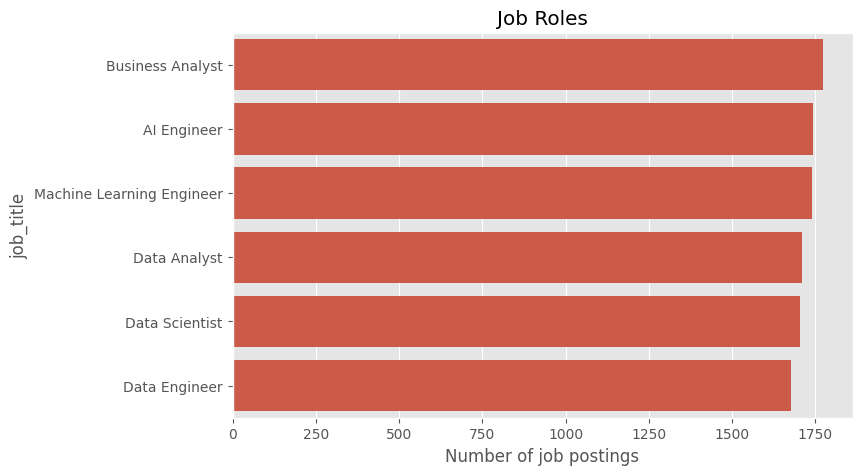

In [131]:
plt.figure(figsize=(8,5))
sns.countplot(
    y='job_title',
    data=df,
    order=df['job_title'].value_counts().index[:]
)
plt.title("Job Roles")
plt.xlabel("Number of job postings")


### Insights
 * The chart shows that Business Analyst, AI Engineer, and Machine Learning Engineer roles have the highest number of job postings.
 * Data Analyst and Data Scientist positions also appear frequently, indicating strong demand for data-related professionals.
 * Data Engineer roles appear slightly less often but remain important for building and maintaining data infrastructure.

Text(0, 0.5, 'Frequency')

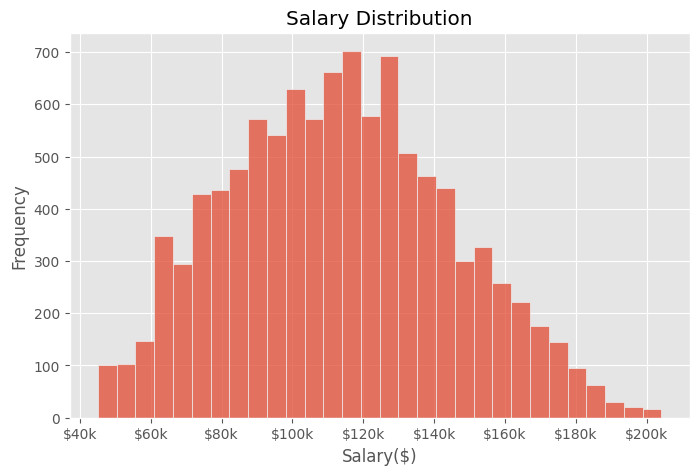

In [132]:
# 2. Salary Distribution
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))
sns.histplot(df['salary'],bins=30)
# format x-axis to show K instead of full numbers
formatter = FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
plt.gca().xaxis.set_major_formatter(formatter)

plt.title("Salary Distribution")
plt.xlabel("Salary($)")
plt.ylabel("Frequency")


### Insights
- **Most salaries fall** between **90k** and **140k**.
- The **highest concentration** is around **110k** – **120k**.
- **Lower salaries** likely represent **entry-level roles**.
- Salaries above **160k** are **less frequent** and may indicate **senior or specialized positions**.

Text(0, 0.5, 'Number of Job Postings')

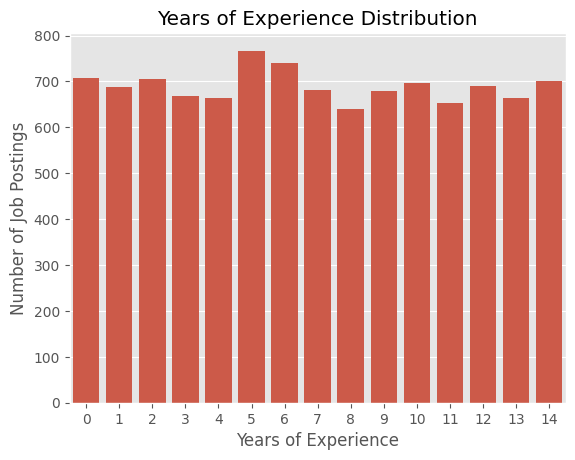

In [133]:
# 3. Experience Distribution
sns.countplot(x="experience_years",data=df)

plt.title("Years of Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Job Postings")



### Insights: 
* The distribution of **job postings across years of experience appears relatively balanced**, with most experience levels ranging between **650 and 770 job postings**.
* The **highest number of job postings** occurs aroung **5 years** of experience, suggesting that many companies prefer candidates with **mid-level experience**.
* Experience levels between **4 and 7 years** also show consistently high demand, indicating that organizations are actively **hiring professionals** who already have several years of industry experience.
* Entry-level positions requiring **0-1 years of experience** appear **slightly less frequently compared to mid-level roles**, which may suggest that companies prfer candidates with **some practical experience**.
* Job postings requiring **10+ years of experience** remain present but **do not dominate the dataset**, indicating that senior roles exist but are **fewer compared to mid-level positions**.

In [134]:
# 4. Skill Demand Analysis
skills = [
    'python',
    'sql',
    'machine_learning',
    'deep_learning',
    'cloud'
]
df[skills].sum().sort_values(ascending=False)

cloud               5291
machine_learning    5254
sql                 5204
deep_learning       5152
python              5101
dtype: int64

Text(0.5, 0, 'Number of Job Postings')

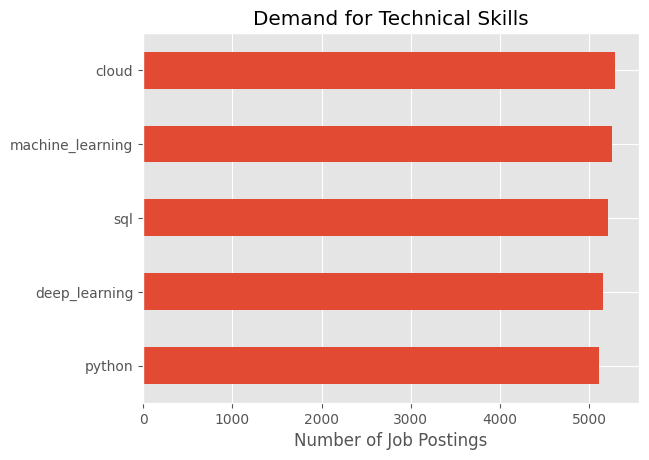

In [135]:
df[skills].sum().sort_values().plot(kind="barh")
plt.title("Demand for Technical Skills")
plt.xlabel("Number of Job Postings")

### Insights:
    - The chart shows that all five technical skills are highly demanded in AI and data science jobs. 
    - Cloud computing apeears slightly more frequently, followed closely by machine learning and SQL.
    - Python also remains a core skill in the field, while deep learning appears slightly less common, suggesting it may be required mainly for specialized AI roles.

Text(0.5, 1.0, 'Top 10 Hiring Industries')

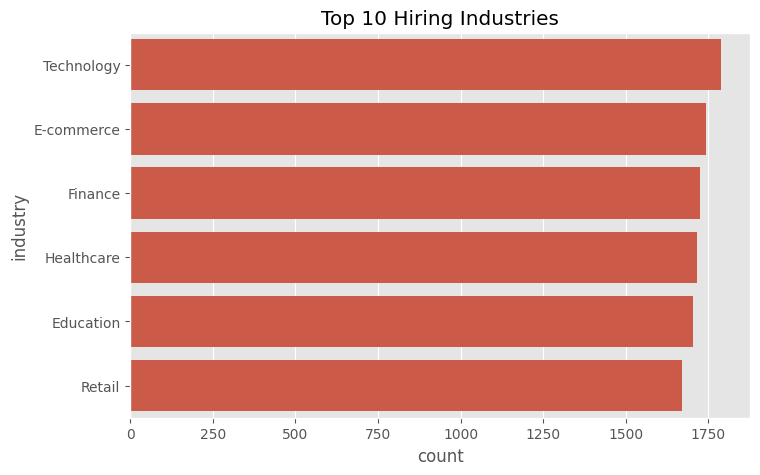

In [136]:
# 5. Industry Distribution 
plt.figure(figsize=(8,5))
sns.countplot(
    y="industry",
    data=df,
    order=df['industry'].value_counts().index[:10]
)

plt.title("Top 10 Hiring Industries")

### Insights:
**Technology leads** in hiring AI and data science professionals, **followed closely by E-commerce, Finance, Healthcare, and Educatoin**. This suggests that demand for data talent is strong across multiple industries, not only within the technology sector.

Text(0.5, 1.0, 'Work Type Distribution ')

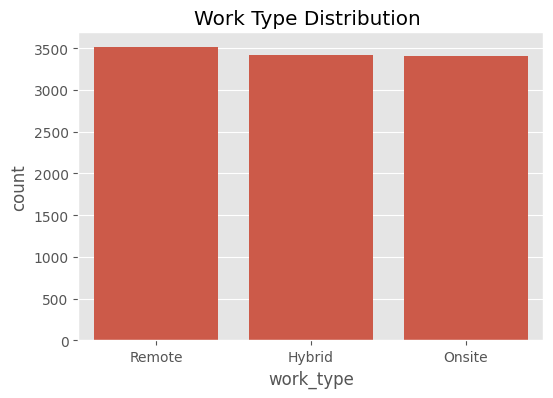

In [137]:
# 6. Remote Work Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='work_type', data=df)
plt.title("Work Type Distribution ")

## Step 4: Feature Relationships


Text(0, 0.5, 'Salary')

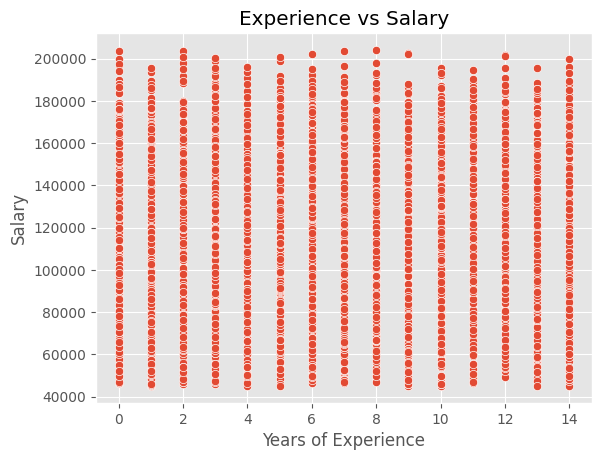

In [138]:
sns.scatterplot(
    x="experience_years",
    y="salary",
    data=df,
)
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

### Insights:
Salary values appear widely distributed across all experience levels, indicating that experience alone does not strongly determine salary in this dataset.

Text(0.5, 1.0, 'Salary Distribution by Job Title')

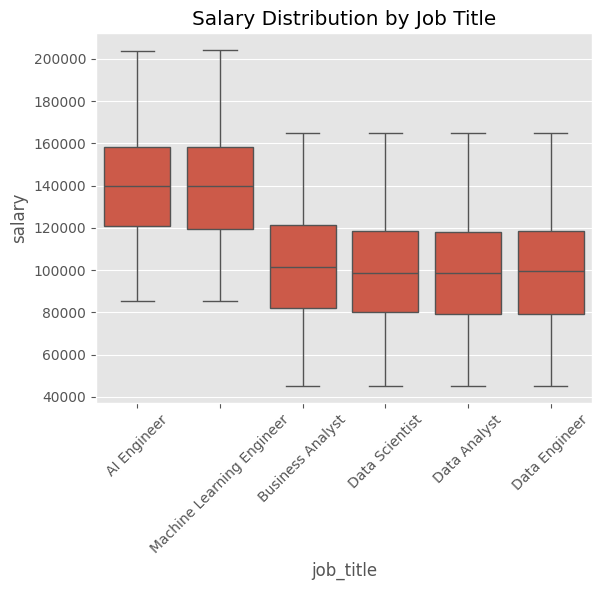

In [139]:
sns.boxplot(
    x="job_title",
    y='salary',
    data=df
)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Title")

### Insights

**AI Engineer and Machine Learning Engineer** roles show the **highest salary** ranges in the dataset. Other roles such as **Data Scientist, Data Analyst, and Business Analyst** have **lower median salaries**, indicating that specialized AI/ML roles tend to offer higher pay.

In [140]:
pd.crosstab(df["country"],df["industry"])

industry,E-commerce,Education,Finance,Healthcare,Retail,Technology
country,,,,,,
Australia,256,256,255,230,230,228
Canada,253,218,248,282,247,240
Germany,247,243,257,240,252,259
India,250,234,239,222,247,278
Singapore,233,256,228,272,237,264
UK,233,266,255,237,235,259
USA,272,231,242,232,223,259


### Insights

The cross-tabulation shows that job postings are relatively evenly distributed across countries and industries. 

However, some patterns appear. For example, the **USA has the highest number of E-commerce jobs**, while **Canada and Singapore show strong demand in Healthcare**. The **Technology industry also appears frequently across multiple countries**, indicating global demand for AI and data professionals.

In [141]:
pd.crosstab(df["country"],df["job_title"])

job_title,AI Engineer,Business Analyst,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer
country,,,,,,
Australia,233,248,219,228,275,252
Canada,267,249,239,260,233,240
Germany,268,262,261,227,248,232
India,244,244,236,243,256,247
Singapore,248,246,253,241,246,256
UK,235,253,267,244,224,262
USA,247,271,236,233,221,251


### Insights

The table shows some country-specific hiring patterns. 

- **Germany has the highest demand for AI Engineers (268)**.
- **The USA shows the highest demand for Business Analysts (271)**.
- **The UK leads in Data Analyst roles (267)**.
- **Canada has the highest demand for Data Engineers (260)**.
- **Australia shows the strongest demand for Data Scientists (275)**.

Overall, demand for AI and data-related roles appears across all countries, indicating a globally distributed job market.

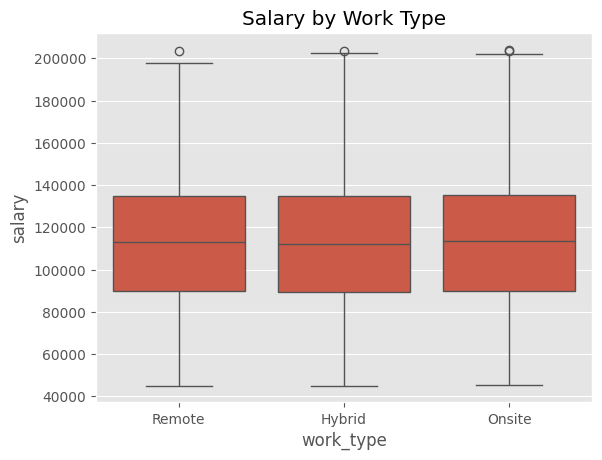

In [142]:
sns.boxplot(
    x='work_type',
    y='salary',
    data=df
)

plt.title("Salary by Work Type")

plt.show()

### Insights

The boxplot shows that salary distributions are very similar across Remote, Hybrid, and Onsite work types. The median salary for all three work arrangements is around **110k–115k** . 

This suggests that work arrangement does not significantly affect salary in this dataset, as all work types show similar salary ranges and distributions.

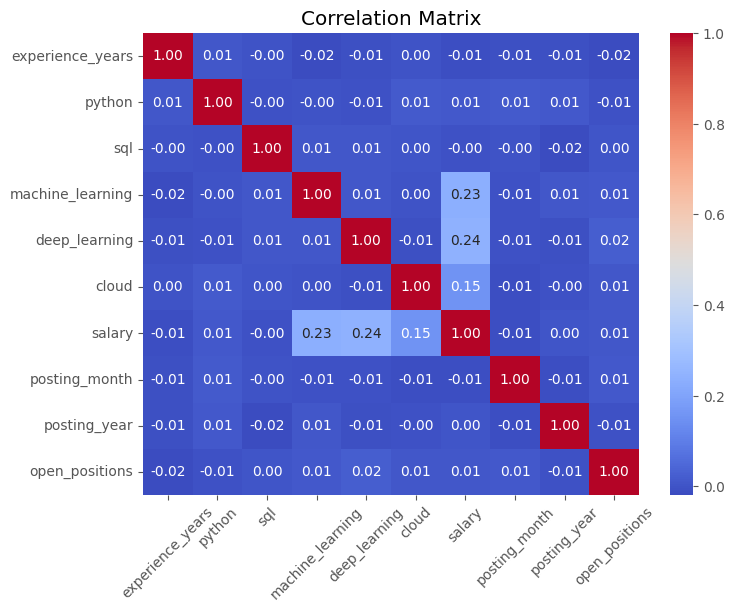

In [143]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

### Key Findings

Most variables show **very weak correlations** with each other, indicating that many features in the dataset are relatively independent.

However, salary shows a moderate positive relationship with **machine learning (0.23)** and **deep learning (0.24)** skills, suggesting that jobs requiring advanced AI expertise tend to offer higher compensation.

**Cloud skills** also show a **smaller positive** correlation with **salary (0.15)**, indicating that cloud computing knowledge may also contribute to higher-paying roles.

In [144]:
df.groupby('industry')['open_positions'].sum().sort_values(ascending=False)

industry
Technology    9149
E-commerce    8657
Finance       8654
Healthcare    8466
Retail        8440
Education     8401
Name: open_positions, dtype: int64

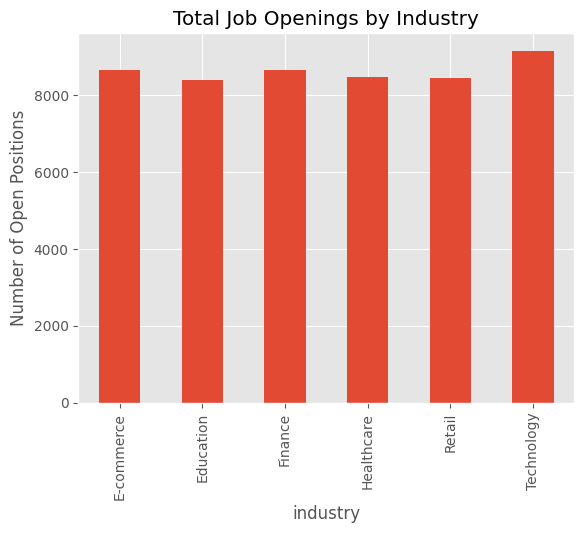

In [145]:
df.groupby('industry')['open_positions'].sum().plot(kind='bar')

plt.title("Total Job Openings by Industry")
plt.ylabel("Number of Open Positions")

plt.show()

### Insights

The chart shows that job openings are relatively evenly distributed across industries. 

However, the technology sector has the highest number of open positions, indicating strong demand for AI and data science professionals in tech-related companies.

Other industries such as finance, healthcare, and e-commerce also contribute significantly to AI job opportunities, suggesting that AI adoption is widespread across multiple sectors.

## Step 5: Final Insights

Based on the exploratory data analysis, several key observations about the AI and data science job market can be identified.

- AI-related roles such as Data Scientist, Data Analyst, and AI Engineer appear consistently across multiple countries, indicating strong global demand for data-driven professionals.

- The technology industry shows the highest number of AI job openings, although other sectors such as finance, healthcare, and e-commerce also contribute significantly.

- Advanced technical skills such as machine learning and deep learning are associated with slightly higher salary levels.

- Salary levels appear widely distributed across experience levels, suggesting that factors such as technical skills and job roles may play a larger role in determining compensation.

Overall, the analysis highlights the growing demand for AI professionals across industries and countries, with strong emphasis on technical expertise and data-related skills.